In [1]:
import matplotlib.pyplot as plt
from statsmodels.base.model import GenericLikelihoodModel
import numpy as np
import cv2
import scienceplots
import tifffile as tiff

from boulder_statistics.analysis.data_product_encyclopedia import DataProductEncyclopedia
from boulder_statistics.analysis.fit_params.weibull_fit_params import WeibullFitParams

plt.style.use('science')
plt.rcParams["figure.figsize"] = (3.5, 3.5 * ((5**0.5 - 1) / 2)) # 3.5
plt.rcParams["figure.dpi"] = 600
%matplotlib inline

import polars as pl
from polars import Expr, LazyFrame, DataFrame
import numpy as np
from pathlib import Path
from typing import Any
import tifffile
from typing import Dict
from typing import Callable


from boulder_statistics.analysis.data_product_encyclopedia import DataProductEncyclopedia

dp = DataProductEncyclopedia(
    data_products_path=Path(r"C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33\.data_products"))

In [2]:
power_law_db = pl.read_parquet(r"MLE_random_sample_fit_data\PowerLaw")
weibull_db = pl.read_parquet(r"MLE_random_sample_fit_data\Weibull")
log_normal_db = pl.read_parquet(r"MLE_random_sample_fit_data\LogNormal")

In [32]:
log_normal_db

seed,aic,bic,numb_alphas,s_max_fitting_alpha,s_min_fitting_alpha,mu,sigma,mu_err,sigma_err,LAD_min,J_min,min_alpha_to_consider
i32,f64,f64,i64,f64,f64,f64,f64,f64,f64,i32,f64,i32
34791,1.8501e6,1.8501e6,129363,8616.625643,22.776133,-4.972953,2.268432,0.126724,0.027809,0,0.7,155
12582,1.8483e6,1.8483e6,129363,18217.221331,22.776133,-4.728107,2.222093,0.117545,0.026505,0,0.7,155
89725,1.8515e6,1.8515e6,129363,34166.764882,22.776133,-4.058933,2.083194,0.091073,0.022286,0,0.7,155
72097,1.8466e6,1.8466e6,129363,20845.303305,23.497827,-5.57859,2.394971,0.155237,0.032003,0,0.7,155
71723,1.8497e6,1.8498e6,129363,34166.764882,22.776133,-8.479012,2.85337,0.308514,0.0506,0,0.7,155
…,…,…,…,…,…,…,…,…,…,…,…,…
22065,641764.083694,641798.444651,39745,34166.764882,24.917094,-3.179026,2.014448,0.212623,0.048085,0,0.7,568
40304,641885.407148,641919.768105,39745,34166.764882,22.776133,-2.446219,1.851371,0.154983,0.038828,0,0.7,568
44545,641553.419401,641587.780358,39745,34166.764882,22.776133,-4.224232,2.218129,0.307384,0.061893,0,0.7,568


In [52]:
pl_df = power_law_db.group_by("min_alpha_to_consider").agg(
    pl.col("q").mean().alias("q_mu"),
    pl.col("q").std().alias("q_std")
).sort("min_alpha_to_consider")

w_df = weibull_db.group_by("min_alpha_to_consider").agg(
    pl.col("lambda").mean().alias("lambda_mu"),
    pl.col("lambda").std().alias("lambda_std"),
    pl.col("k").mean().alias("k_mu"),
    pl.col("k").std().alias("k_std")
).filter(pl.col("min_alpha_to_consider") < 1e4).sort("min_alpha_to_consider")

ln_df = log_normal_db.group_by("min_alpha_to_consider").agg(
    pl.col("mu").mean().alias("mu_mu"),
    pl.col("mu").std().alias("mu_std"),
    pl.col("sigma").mean().alias("sigma_mu"),
    pl.col("sigma").std().alias("sigma_std")
).filter(pl.col("mu_mu") > -200).sort("min_alpha_to_consider")

In [53]:
import pymannkendall as mk

# === PL === 

result = mk.original_test(
    pl_df.sort("min_alpha_to_consider")[f"q_mu"]
)
print(result)

# === W ===

result = mk.original_test(
    w_df.sort("min_alpha_to_consider")[f"lambda_mu"]
)
print(result)

result = mk.original_test(
    w_df.sort("min_alpha_to_consider")[f"k_mu"]
)
print(result)

# === LN ===

result = mk.original_test(
    ln_df.sort("min_alpha_to_consider")[f"mu_mu"]
)
print(result)

result = mk.original_test(
    ln_df.sort("min_alpha_to_consider")[f"sigma_mu"]
)
print(result)

Mann_Kendall_Test(trend='increasing', h=np.True_, p=np.float64(0.01226606138621289), z=np.float64(2.5043961347997645), Tau=np.float64(0.6444444444444445), s=np.float64(29.0), var_s=125.0, slope=np.float64(0.024426694217521704), intercept=np.float64(1.2062057035215645))
Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(0.4277105102974643), z=np.float64(-0.793115538912532), Tau=np.float64(-0.1794871794871795), s=np.float64(-14.0), var_s=268.6666666666667, slope=np.float64(-2.4129497271483827e-08), intercept=np.float64(3.372666017301758e-07))
Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(0.4277105102974643), z=np.float64(-0.793115538912532), Tau=np.float64(-0.1794871794871795), s=np.float64(-14.0), var_s=268.6666666666667, slope=np.float64(-0.00023661349888409646), intercept=np.float64(0.10260504753124015))
Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(0.5480055723613093), z=np.float64(-0.6007514091861106), Tau=np.float64(-0.23809523809523808), 

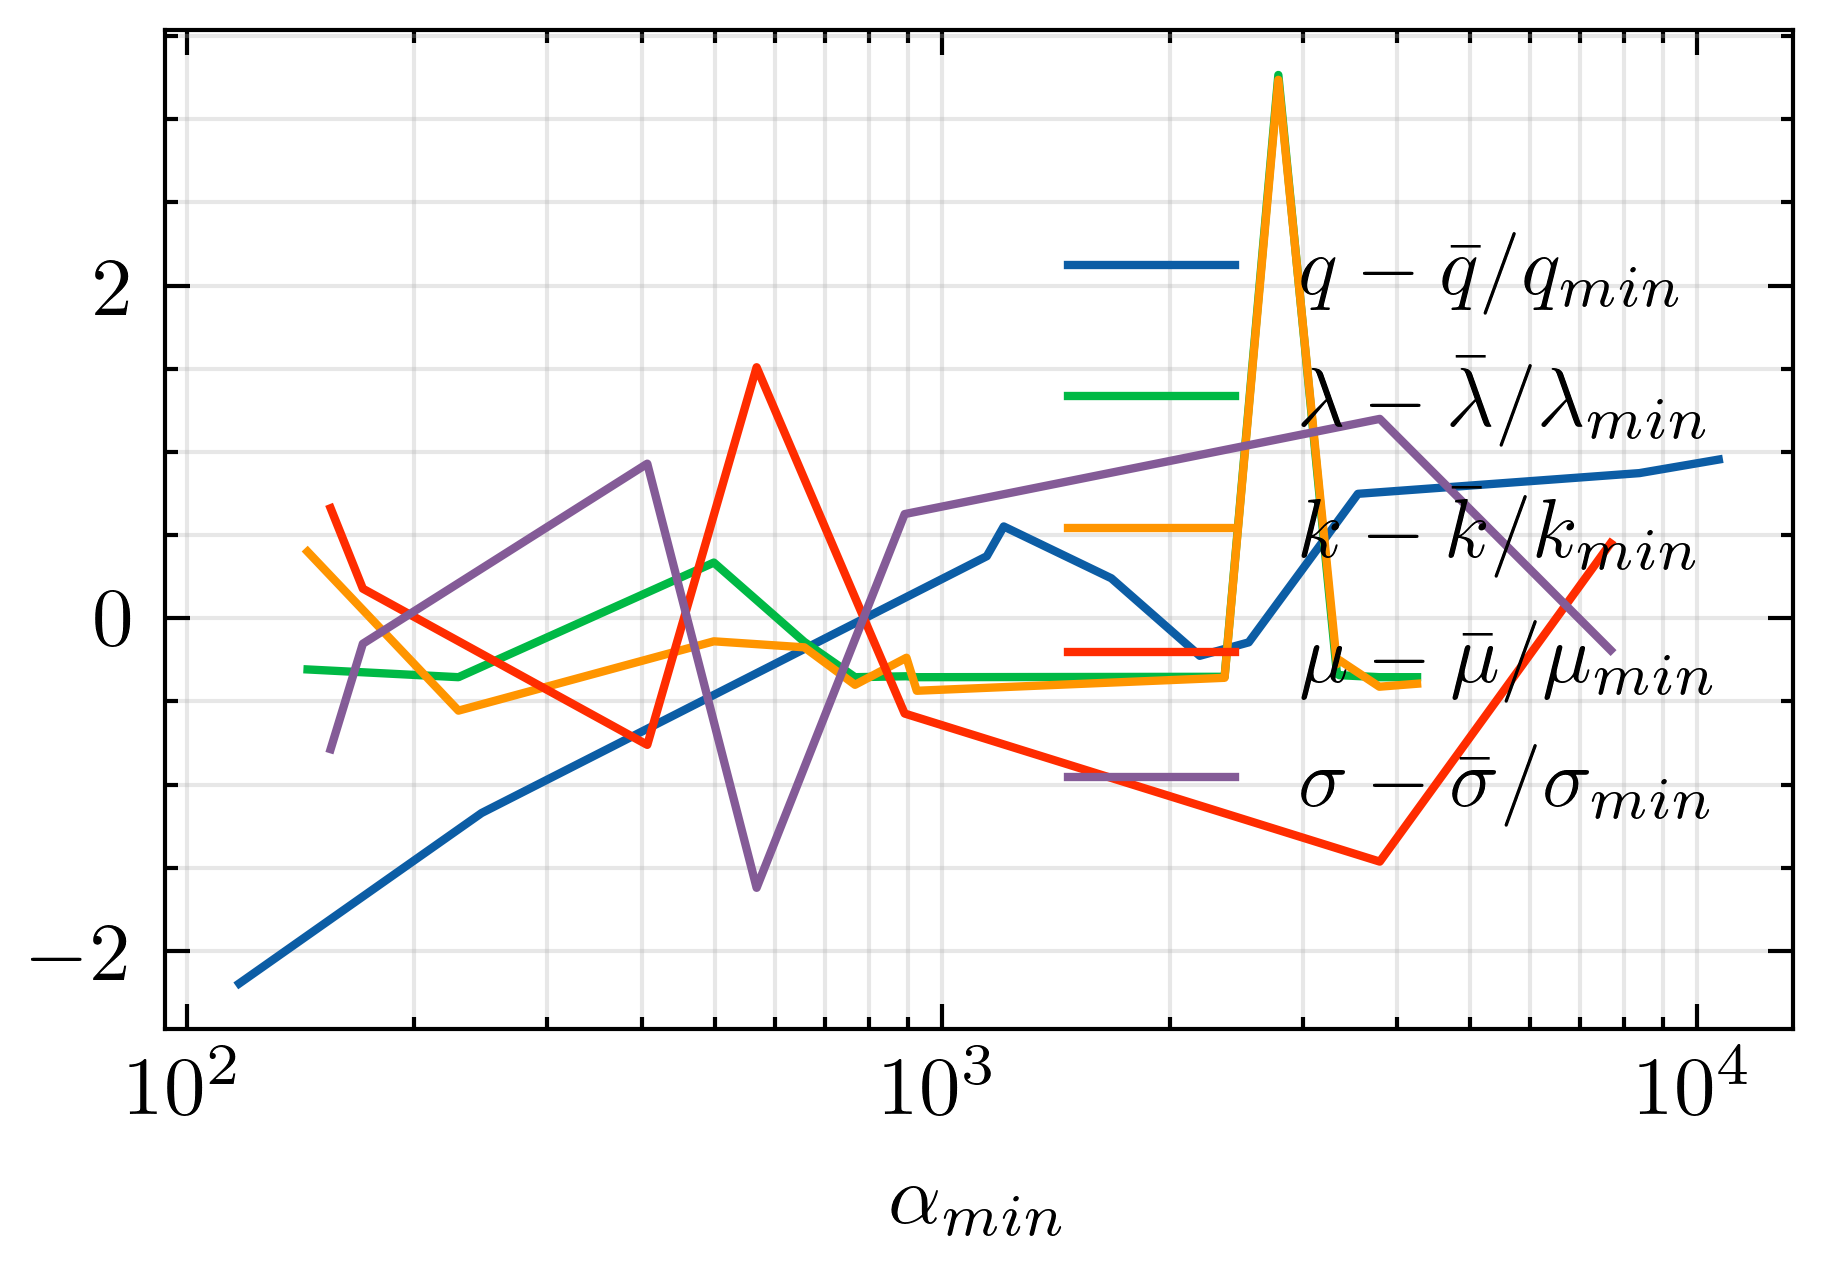

In [59]:
plot_param  = lambda xs, ys, yerrs, c, symbol : plt.plot(
    xs, (ys - ys.mean()) / ys.std(), color = c, label = rf"${symbol} - \bar{{{symbol}}}/{symbol}_{{min}}$"
)

# plt.errorbar(
#     xs,
#     (ys - ys.mean())/ ys.std(),
#     yerr = yerrs / ys.std(),
#     marker=".",
#     capsize=2,
#     linestyle="none",
#     ms = 3,
#     color = c,
#     label = f"${symbol}/{symbol}_{{min}}$"
# )

plot_param(pl_df["min_alpha_to_consider"], pl_df["q_mu"], pl_df["q_std"], "C0", "q")

plot_param(w_df["min_alpha_to_consider"], w_df["lambda_mu"], w_df["lambda_std"], "C1", r"\lambda")
plot_param(w_df["min_alpha_to_consider"], w_df["k_mu"], w_df["k_std"], "C2", r"k")

plot_param(ln_df["min_alpha_to_consider"], ln_df["mu_mu"], ln_df["mu_std"], "C3", r"\mu")
plot_param(ln_df["min_alpha_to_consider"], ln_df["sigma_mu"], ln_df["sigma_std"], "C4", r"\sigma")

# plt.ylim([-1, 1])
plt.xscale("log")
plt.xlabel(r"$\alpha_{min}$")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()

In [ ]:
columns_to_select = ["aic", "numb_alphas"]

aic_db = pl.concat([
    power_law_db.select(columns_to_select).with_columns(pl.lit("PL").alias("fit_type")),
    weibull_db.select(columns_to_select).with_columns(pl.lit("W").alias("fit_type")),
    log_normal_db.select(columns_to_select).with_columns(pl.lit("LN").alias("fit_type"))
]).with_columns(
    (pl.col("aic") - pl.col("aic").min()).alias("delta_aic")
)

aic_db

aic,numb_alphas,fit_type,delta_aic
f64,i64,str,f64
2.3019e6,167084,"""PL""",2.2823e6
2.3014e6,167084,"""PL""",2.2819e6
2.3025e6,167084,"""PL""",2.2830e6
2.3006e6,167084,"""PL""",2.2811e6
2.3009e6,167084,"""PL""",2.2814e6
…,…,…,…
641764.083694,39745,"""LN""",622214.758696
641885.407148,39745,"""LN""",622336.08215
641553.419401,39745,"""LN""",622004.094403


In [ ]:
# aic_db = aic_db.join(
#         aic_db.group_by("numb_alphas").agg(pl.col("aic").min().alias("min_aic_for_numb_alphas")),
#         on = "numb_alphas",
#     ).with_columns(
#         (pl.col("aic") - pl.col("min_aic_for_numb_alphas")).alias("delta_aic")
#     )

# aic_db

In [ ]:
aic_db.group_by("fit_type").agg(
    pl.col("delta_aic").mean().alias("rel_mean_aic"),
    pl.col("delta_aic").std().alias("std_aic"),
    pl.col("delta_aic").min().alias("rel_min_aic"),
    pl.col("delta_aic").max().alias("rel_max_aic"),
    pl.len()
)

fit_type,rel_mean_aic,std_aic,rel_min_aic,rel_max_aic,len
str,f64,f64,f64,f64,u32
"""LN""",687175.762763,684352.57748,13225.209971,1.8330e6,160
"""W""",447704.416972,546069.966561,0.0,1.9345e6,280
"""PL""",470129.040445,706140.214145,1110.210253,2.2920e6,200


In [ ]:
import numpy as np
import polars as pl

types = aic_db["fit_type"].unique().sort().to_list()

samples = {
    t: aic_db.filter(pl.col("fit_type") == t)["delta_aic"].to_numpy()
    for t in types
}

n_boot = 10000
rng = np.random.default_rng()

# Store bootstrap means
boot_means = {t: np.empty(n_boot) for t in types}

# Generate bootstrap means
for i in range(n_boot):
    for t, x in samples.items():
        boot = rng.choice(x, size=len(x), replace=True)
        boot_means[t][i] = boot.mean()

# Probability each mean is the smallest
wins = {t: 0 for t in types}

for i in range(n_boot):
    means = {t: boot_means[t][i] for t in types}
    winner = min(means, key=means.get)
    wins[winner] += 1

# Report results
for t in types:
    mean = boot_means[t].mean()
    se = boot_means[t].std(ddof=1)
    lo, hi = np.percentile(boot_means[t], [2.5, 97.5])

    print(
        f"{t:10s}: "
        f"mean = {mean:.3f} ± {se:.3f} "
        f"(95% CI [{lo:.3f}, {hi:.3f}]), "
        f"P(smallest) = {wins[t]/n_boot:.3%}"
    )

LN        : mean = 686421.631 ± 53779.955 (95% CI [582209.759, 793350.574]), P(smallest) = 0.000%
PL        : mean = 469737.952 ± 49488.265 (95% CI [376815.642, 569720.505]), P(smallest) = 35.430%
W         : mean = 447353.428 ± 32588.334 (95% CI [385235.791, 511524.949]), P(smallest) = 64.570%
